In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="geemap.conversion")

In [2]:
import sys
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")

# Para ver el entorno conda específico
import os
print(f"CONDA_DEFAULT_ENV: {os.environ.get('CONDA_DEFAULT_ENV', 'No conda env')}")

Python executable: /home/diego/miniconda3/envs/ndvi2gif_clean/bin/python
Python version: 3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12) 
[GCC 13.3.0]
CONDA_DEFAULT_ENV: ndvi2gif_clean


In [3]:
import ee
import geemap
import matplotlib.pyplot as plt
from ndvi2gif import NdviSeasonality
from ndvi2gif import NdviSeasonality
from ndvi2gif.timeseries import TimeSeriesAnalyzer, SpatialTrendAnalyzer
print("✓ Módulos importados correctamente")

# Authenticate & initialize Earth Engine
ee.Authenticate()
ee.Initialize()

✓ Módulos importados correctamente


In [4]:
# Create interactive map
Map = geemap.Map()
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [5]:
# Select an area that cover your area of interest
roi = Map.draw_last_feature

There we go again...
Using MODIS Terra + Aqua LST (maximum coverage)
Using all Sentinel-1 orbits (ascending + descending).
Applying S1 ARD preprocessing:
  - Speckle filter: REFINED_LEE
  - Terrain correction: True
  - Terrain model: VOLUME
Using point coordinates: (0.838838, 40.705826)
Extracting 48 temporal periods...
Progress: 48/48 (100.0%)
Successfully extracted 48 data points
Figure saved to rice_comprehensive.png


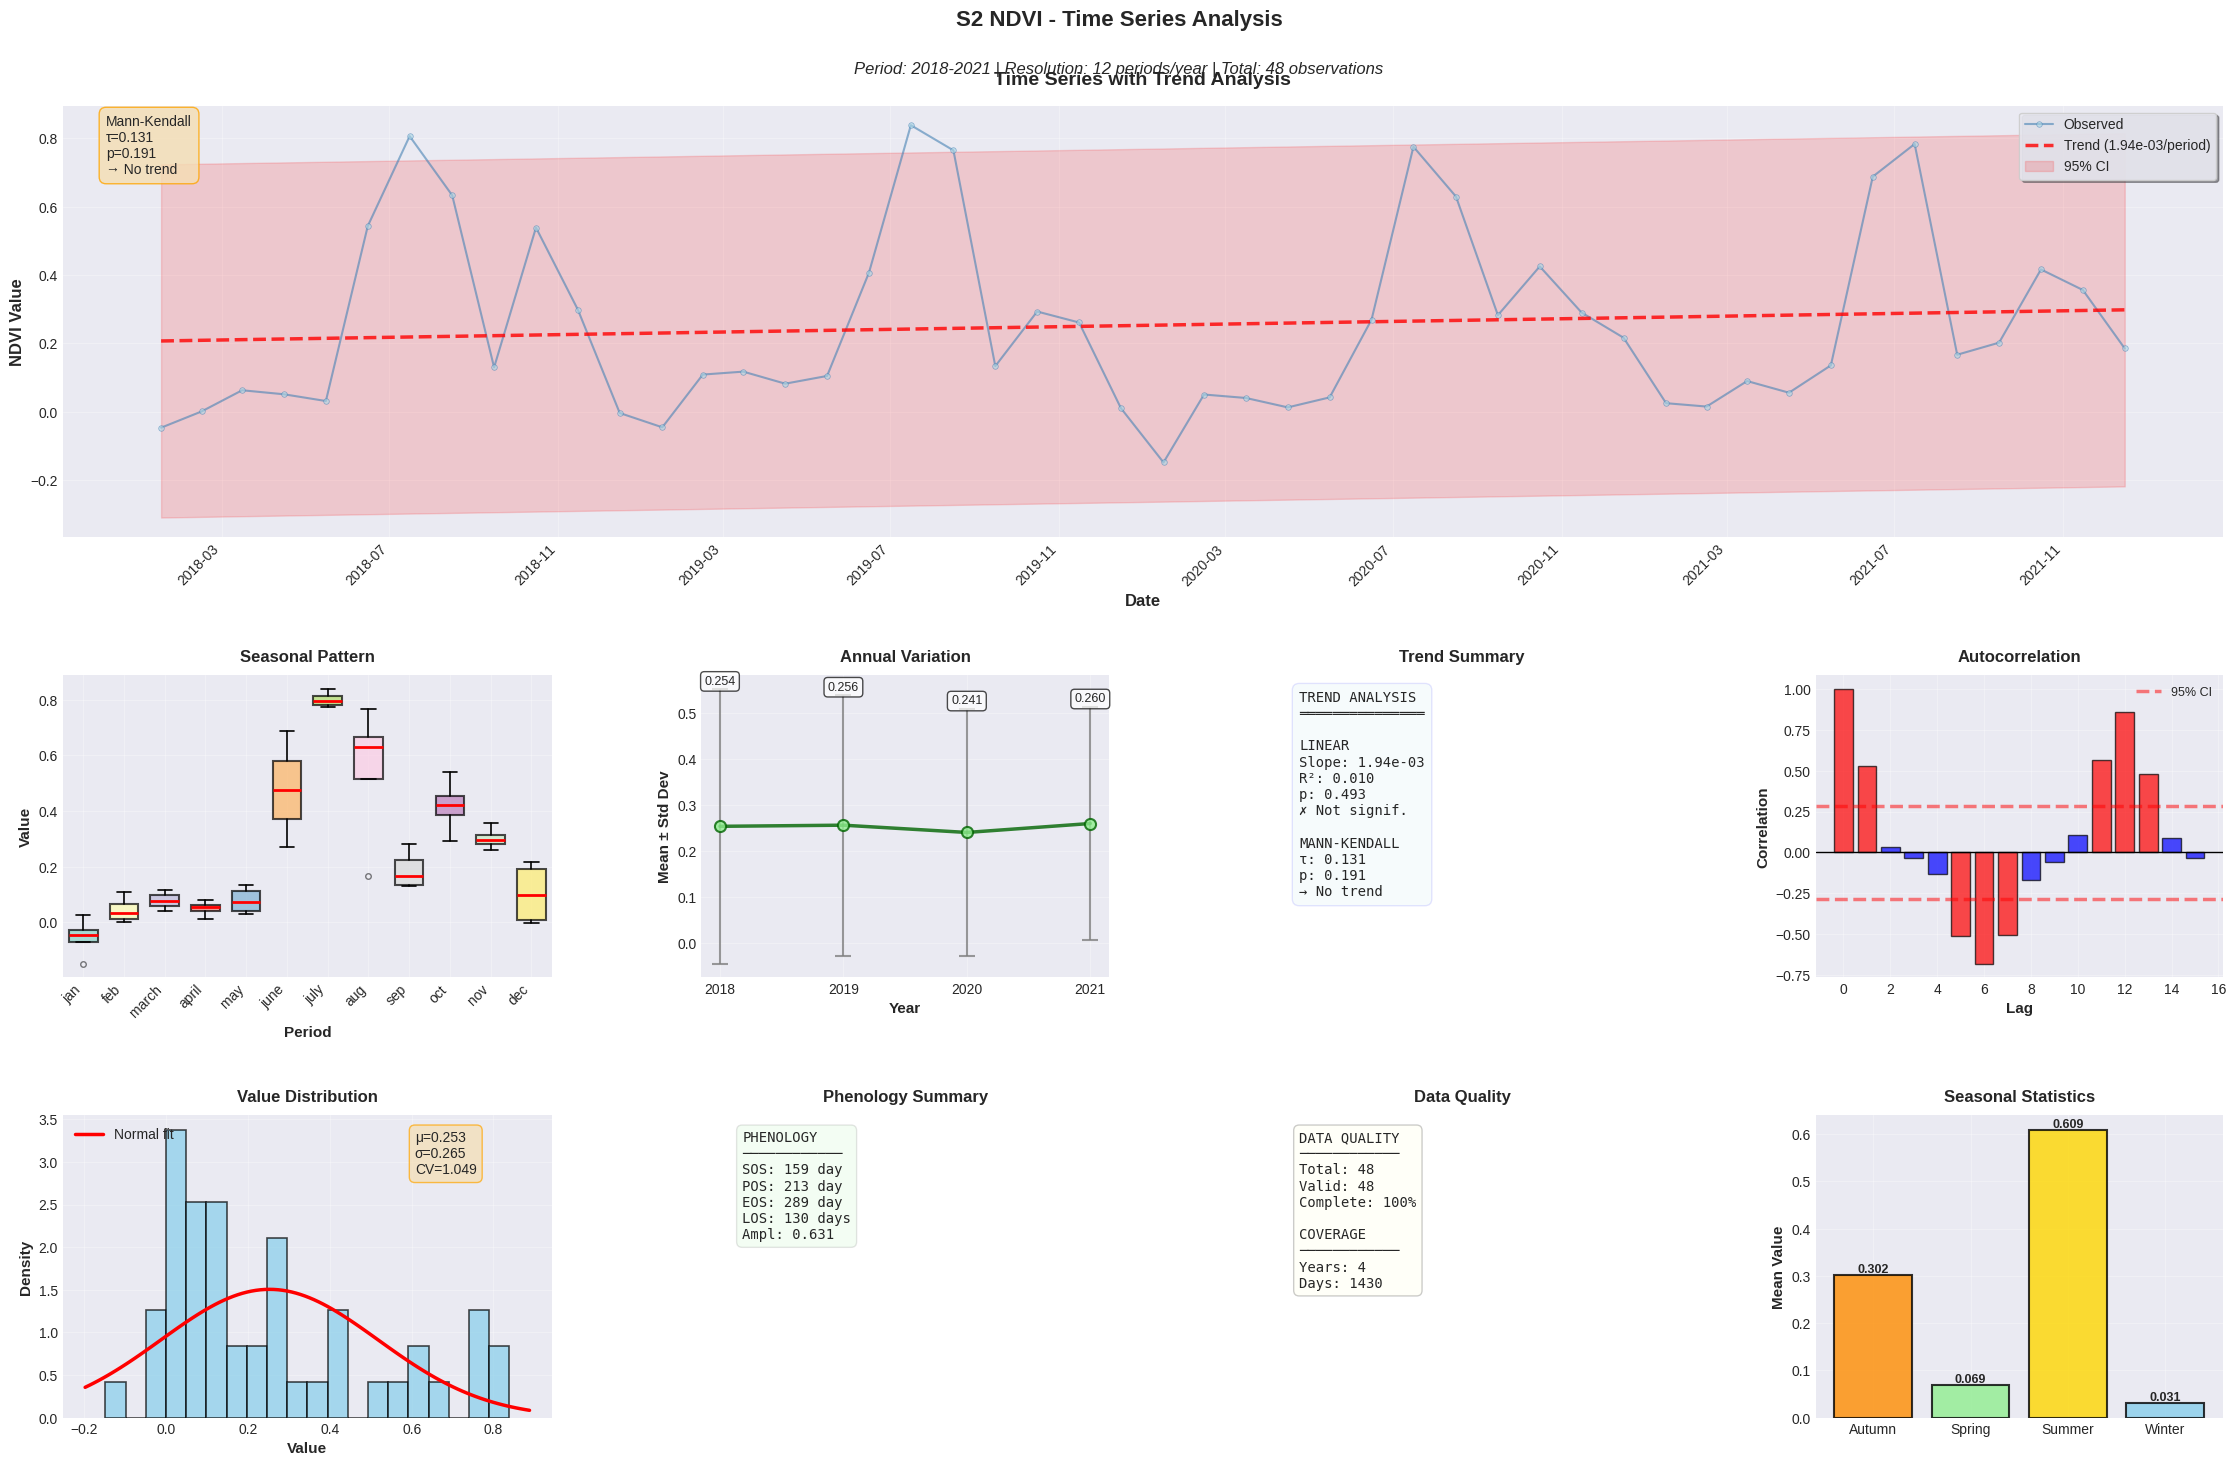

Using cached time series data
Phenological analysis saved to rice_phenology_threshold.png


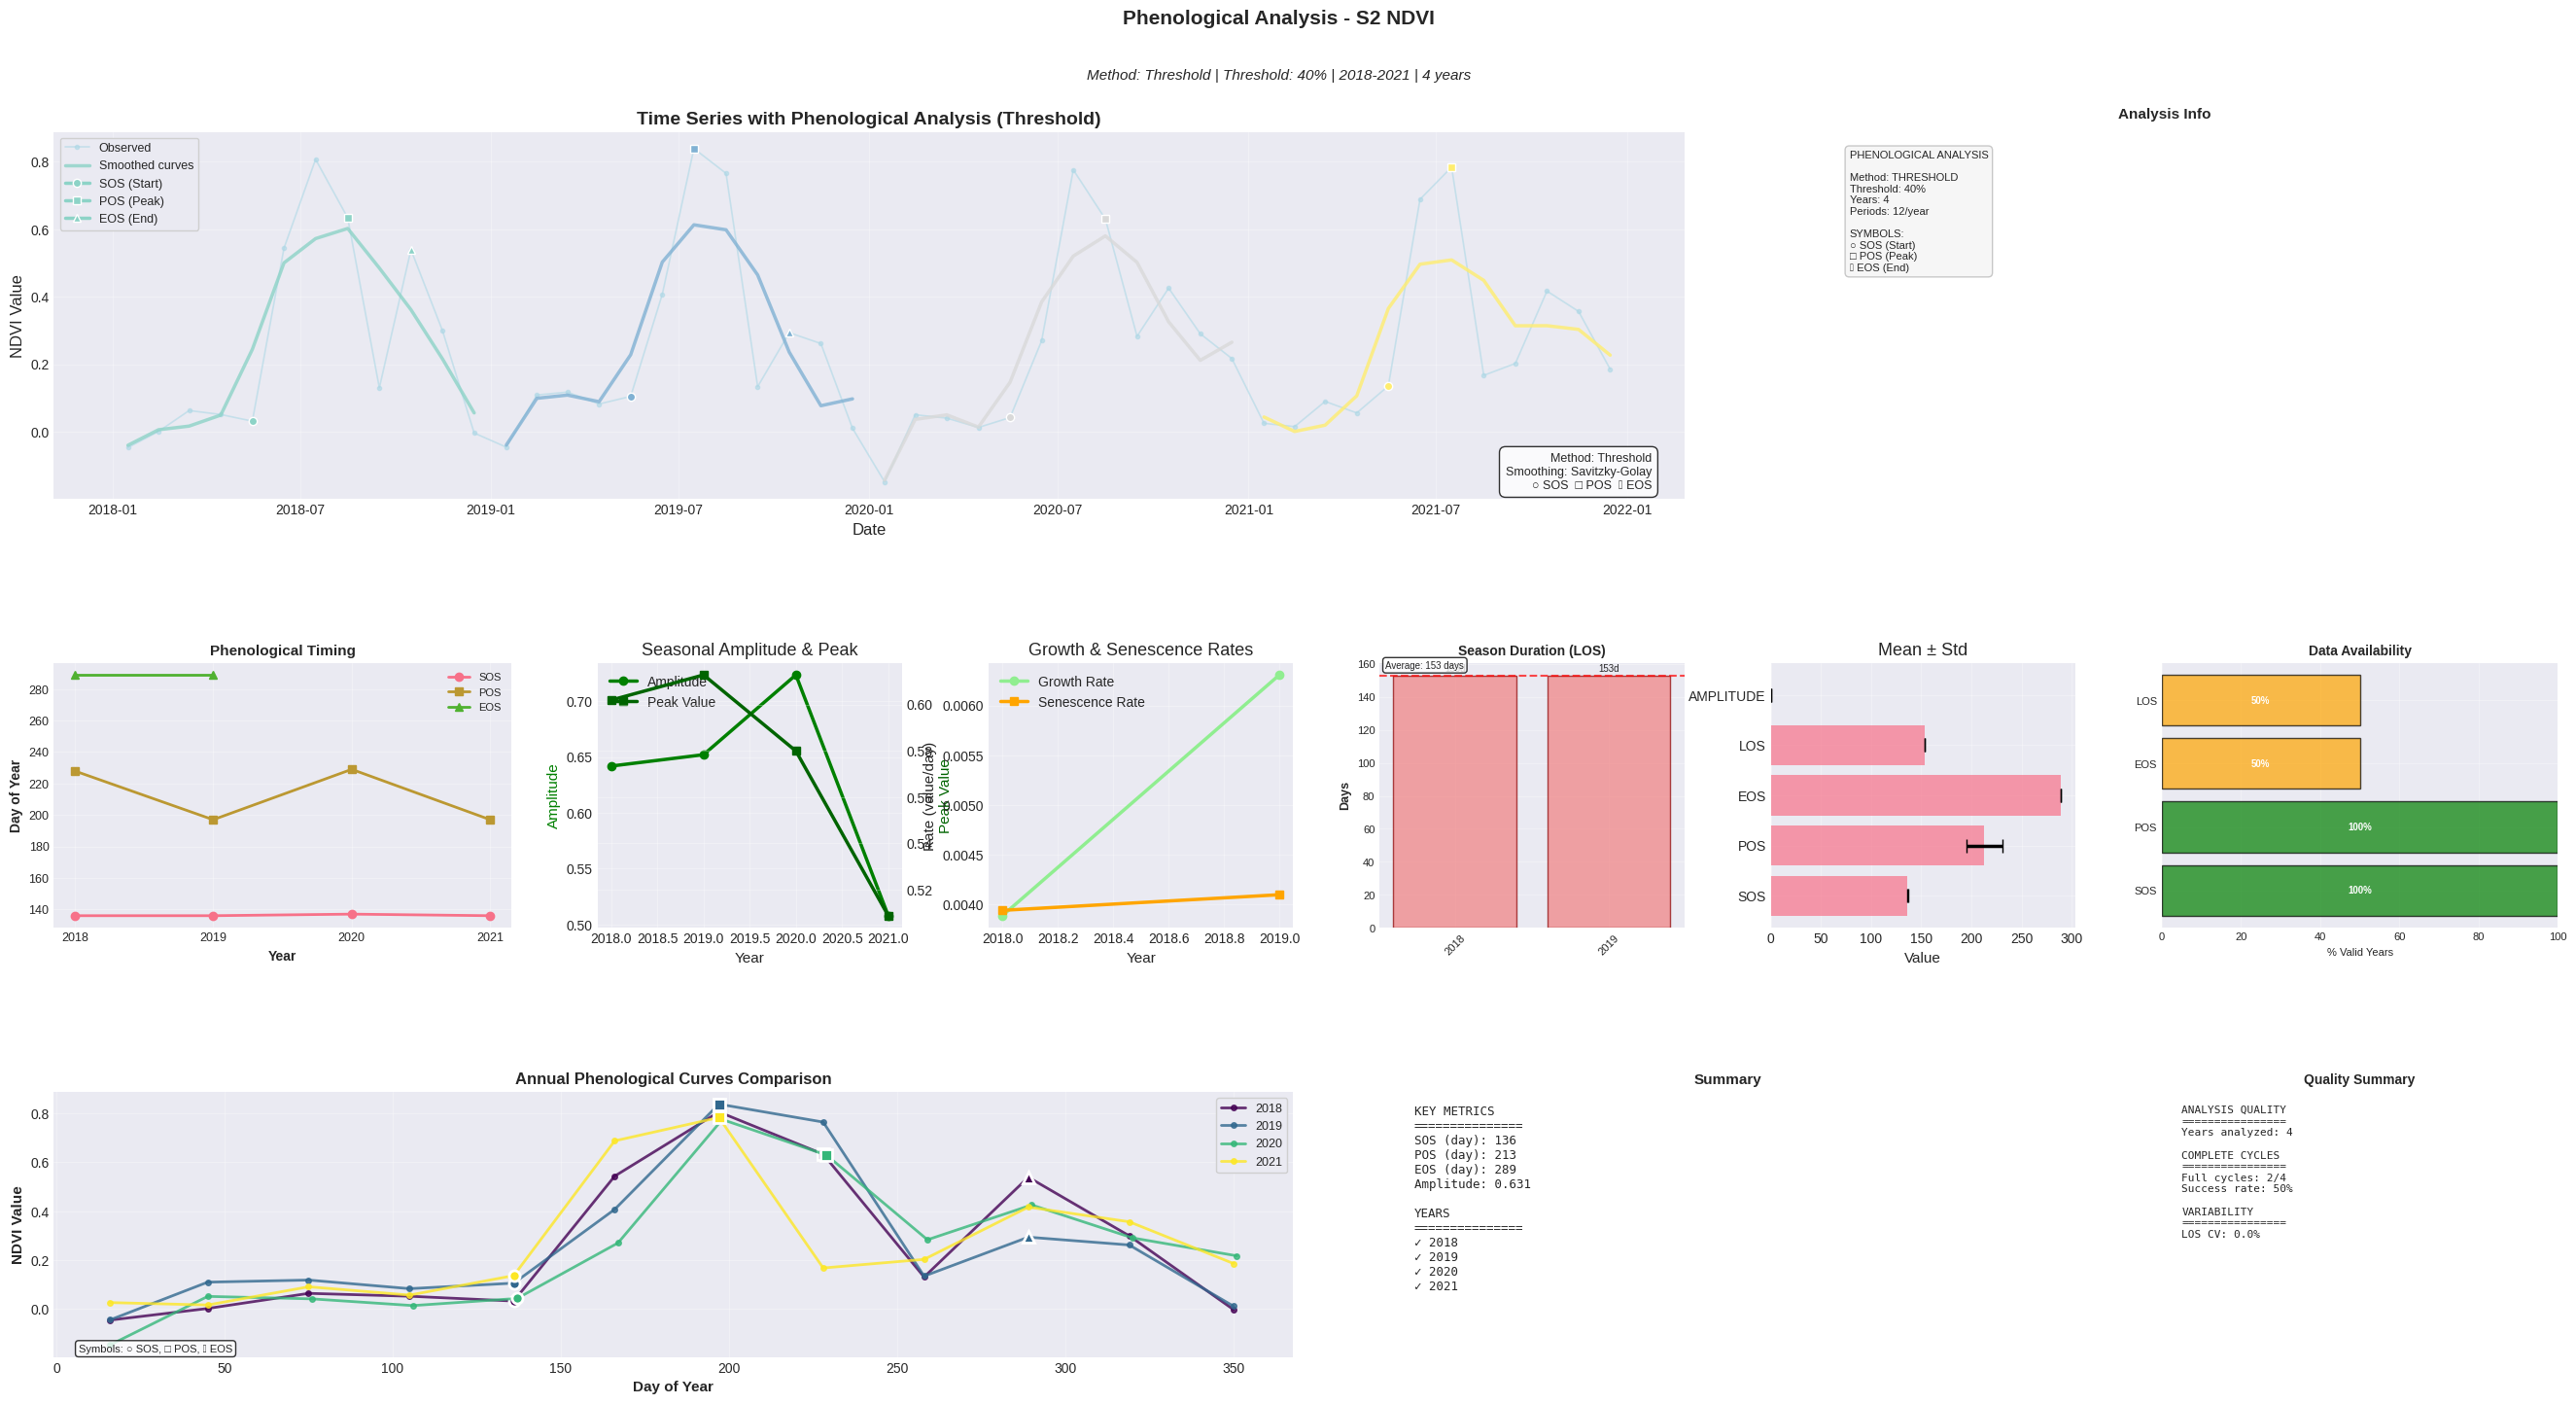

Using cached time series data
Phenological analysis saved to rice_phenology_derivative.png


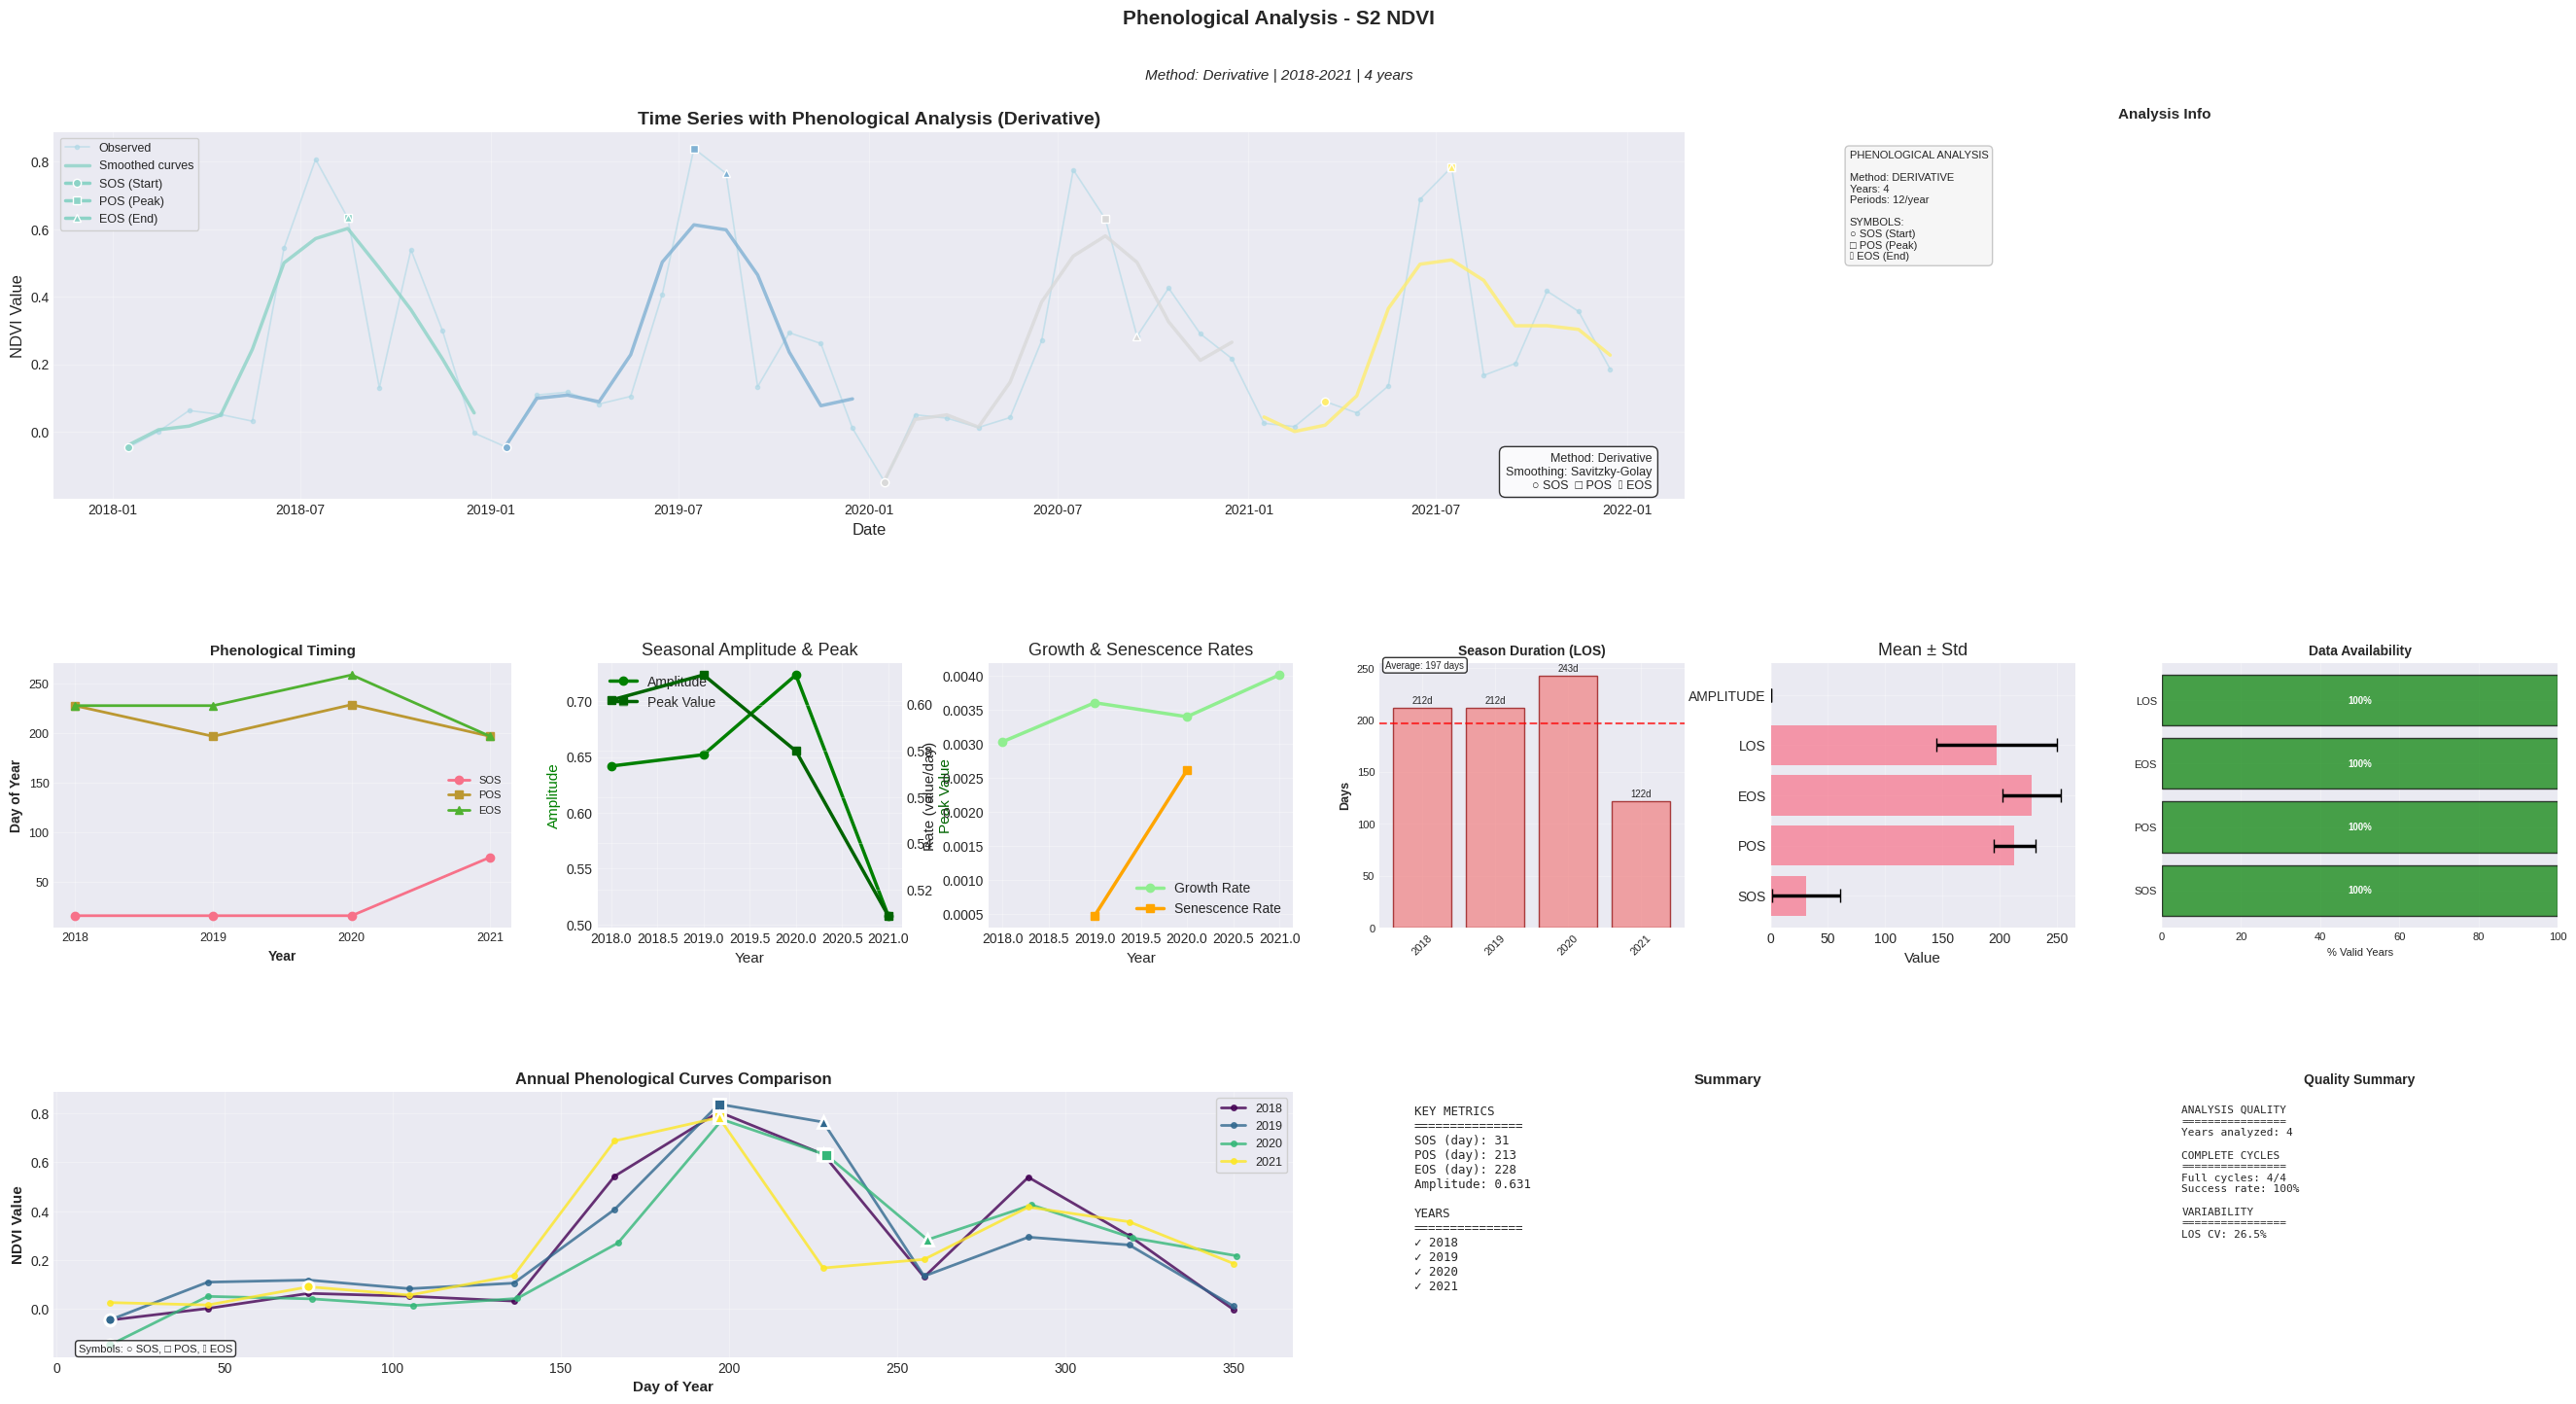

Using cached time series data
Phenological analysis saved to rice_phenology_logistic.png


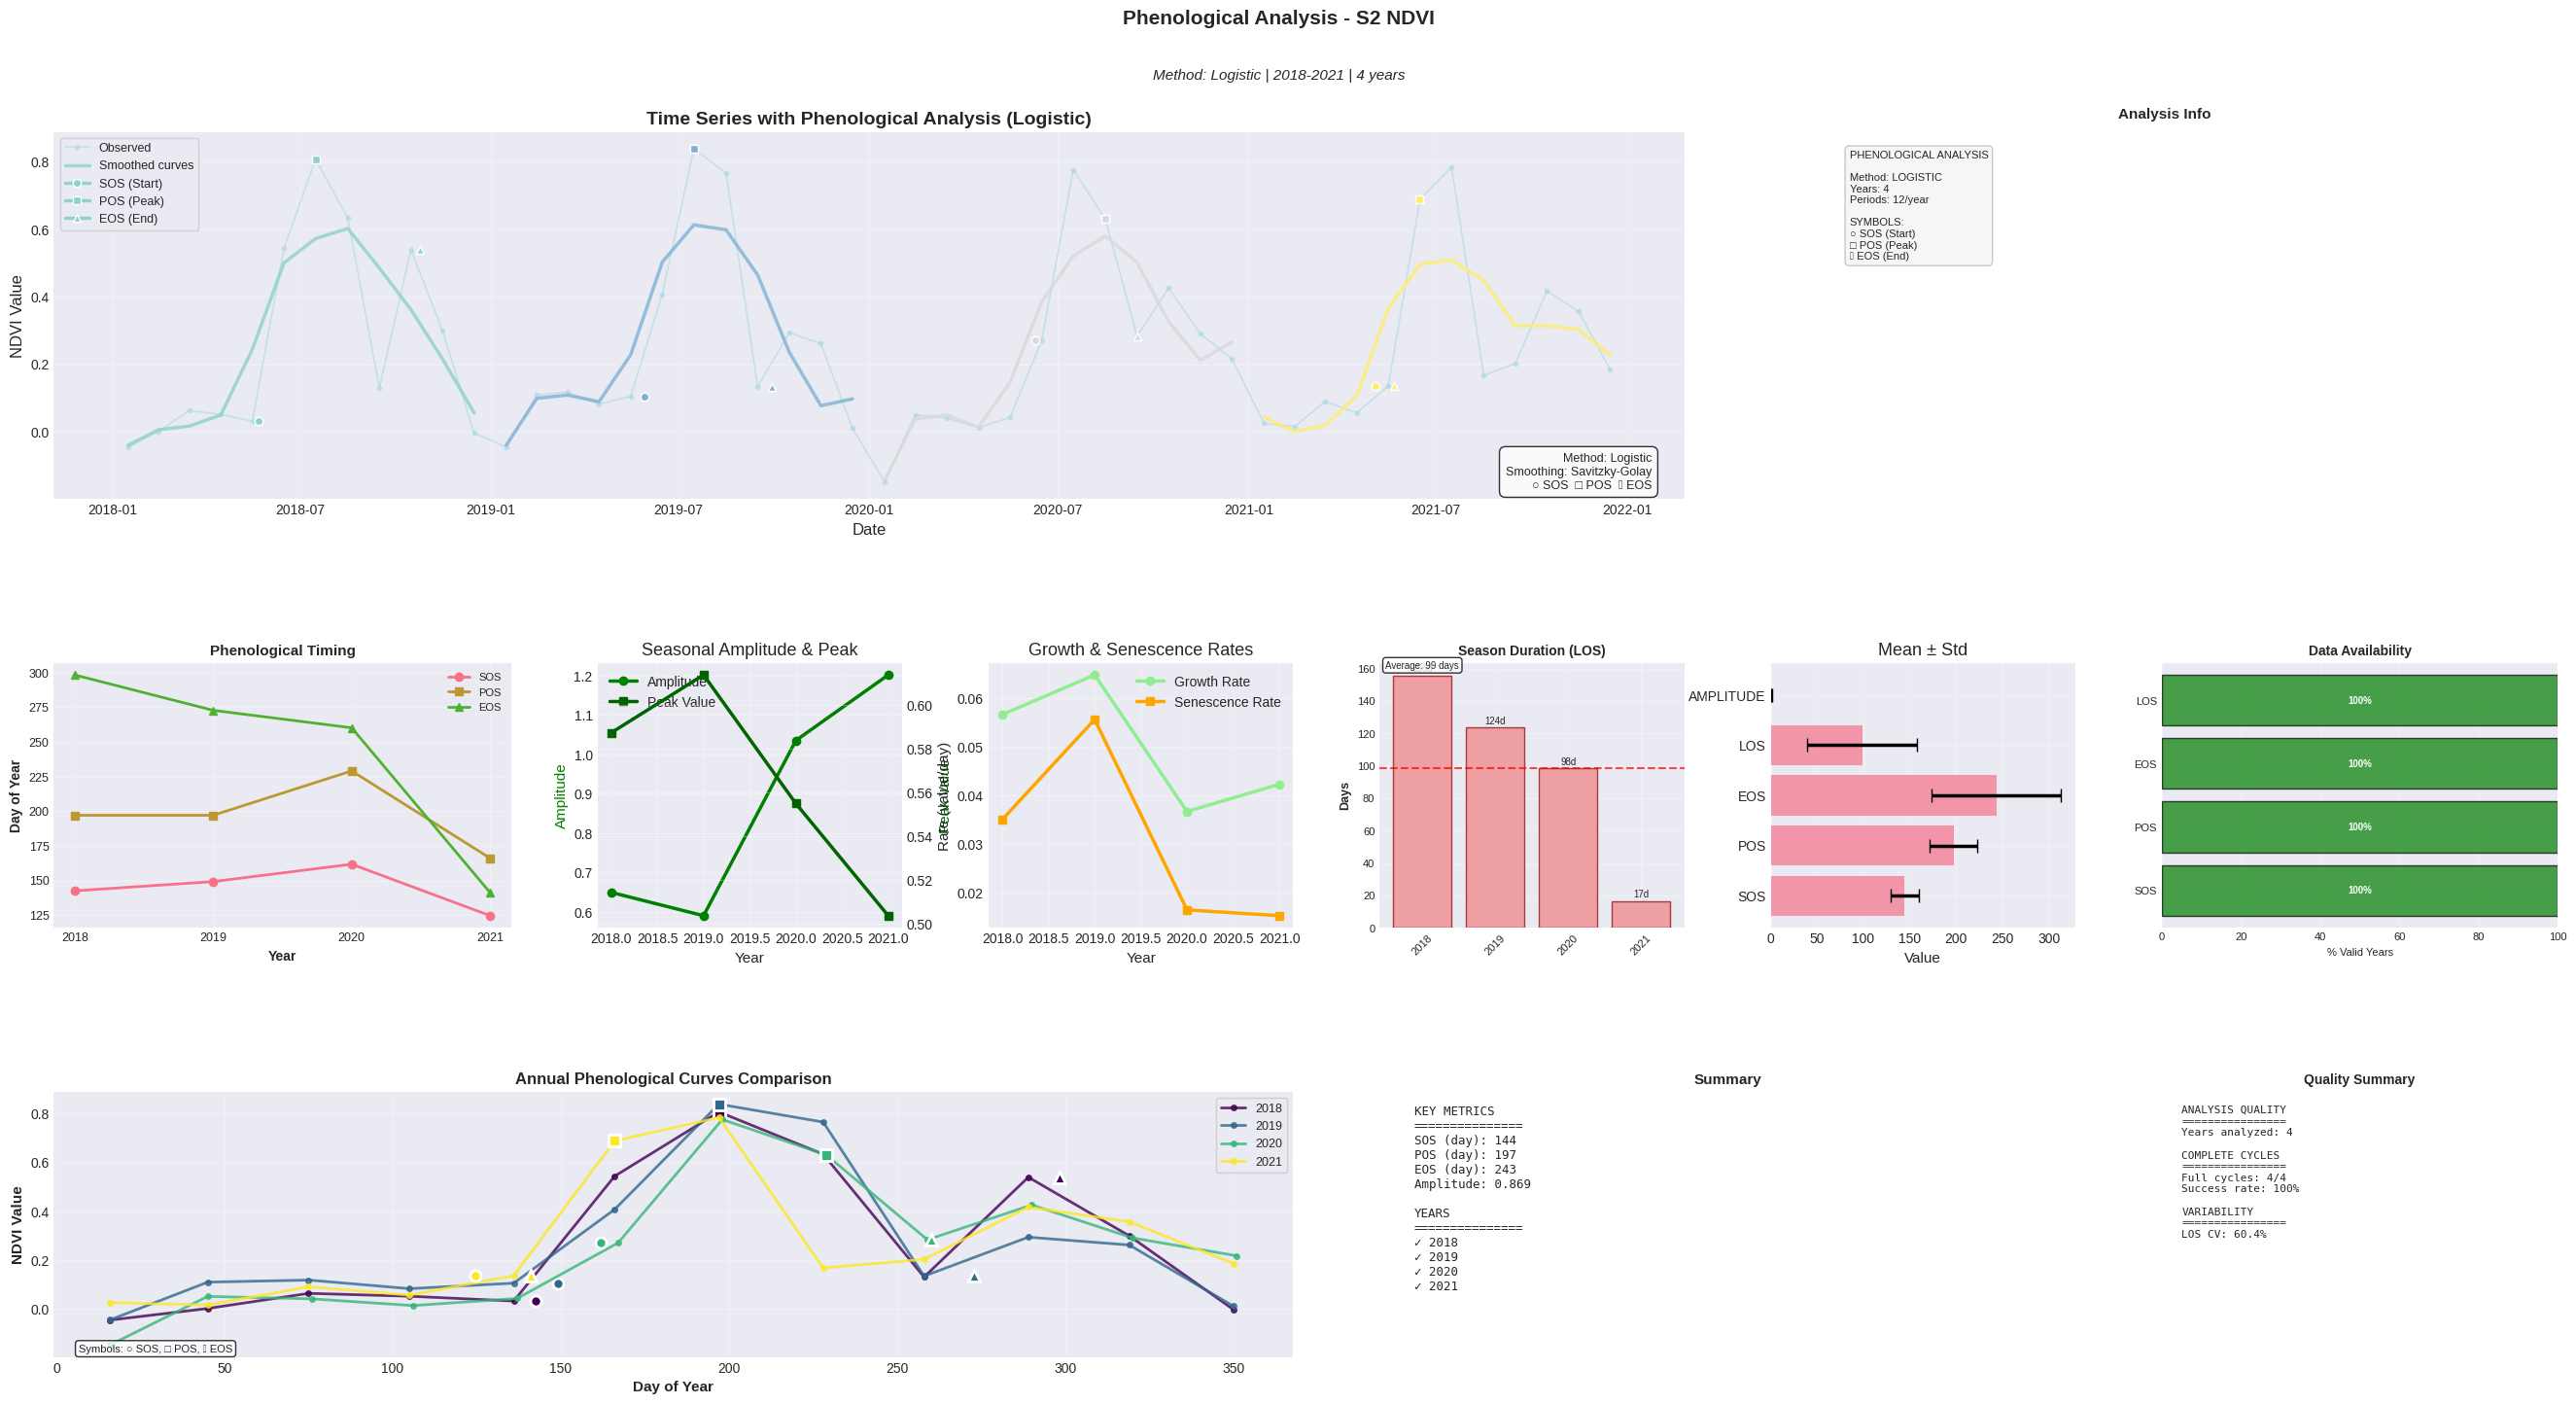

In [6]:
# Ejemplo completo con coordenadas de arroz optimizadas
import ee
import geemap
import numpy as np
import pandas as pd
from ndvi2gif import NdviSeasonality
from ndvi2gif.timeseries import TimeSeriesAnalyzer

ee.Initialize()

processor = NdviSeasonality(
    roi=roi,
    periods=12,
    start_year=2018,
    end_year=2022,
    sat='S2',
    index='ndvi',
    key='median'
)

ts_analyzer = TimeSeriesAnalyzer(processor)
isla_mayor = (-6.189970, 37.141442)
delta_del_ebro = (0.838838, 40.705826)
palencia = (-5.676501, 42.418859)
lebrija = (-6.063629, 36.985864)
california = (-119.422422, 35.643278)

# 1. Análisis comprensivo (1 gráfico)
fig1 = ts_analyzer.plot_comprehensive_analysis(
    point=delta_del_ebro,
    figsize=(24, 16),
    save_path='rice_comprehensive.png'
)

# 2. Análisis fenológico threshold (1 gráfico)
fig2 = ts_analyzer.plot_phenology_analysis(
    point=delta_del_ebro,
    method='threshold',
    threshold_percentile=40,
    figsize=(28, 18),
    save_path='rice_phenology_threshold.png'
)

# 3. Análisis fenológico derivative (1 gráfico)
fig3 = ts_analyzer.plot_phenology_analysis(
    point=delta_del_ebro,
    method='derivative',
    figsize=(28, 18),
    save_path='rice_phenology_derivative.png'
)

# 3. Análisis fenológico derivative (1 gráfico)
fig4 = ts_analyzer.plot_phenology_analysis(
    point=delta_del_ebro,
    method='logistic',
    figsize=(28, 18),
    save_path='rice_phenology_logistic.png'
)